# YOLOv8 Kurgan Detection: Colab Training From GitHub + Google Drive

This notebook is designed for Google Colab.

Workflow:

1. Mount Google Drive.
2. Clone the GitHub repository.
3. Load the YOLO bbox dataset from Google Drive.
4. Optionally build filtered dataset variants `v2` or `v4`.
5. Train YOLOv8.
6. Run optional threshold validation.
7. Save training artifacts as a zip archive back to Google Drive.

The full dataset, model weights, and `runs/` directories should stay outside GitHub.

## 1. Configuration

Edit this cell before running. The default values reproduce the current `v4` balanced experiment.

In [3]:
from pathlib import Path

# GitHub repository
REPO_URL = "https://github.com/MataNerdy/Geodata_Archaeology_CV.git"
BRANCH = "main"
PROJECT_SUBDIR = "04_detection_yolo"

# Dataset on Google Drive.
# Expected zip content can be either:
#   dataset_yolo_bbox/
# or a ready filtered dataset folder with images/, labels/, dataset.yaml.
DRIVE_DATASET_ZIP = "/content/drive/MyDrive/Share/Geodata/dataset_yolo_bbox.zip"
DATA_ROOT = Path("/content/dataset")
SOURCE_DATASET_DIR = DATA_ROOT / "dataset_yolo_bbox"

# Choose one:
#   "v2"       -> kurgan-only Li/Ae baseline
#   "v4"       -> balanced clean Li/Ae dataset
#   "prebuilt" -> use SOURCE_DATASET_DIR as-is
DATASET_VARIANT = "v4"

# YOLO training config
MODEL_NAME = "yolov8s.pt"
IMGSZ = 1024
EPOCHS = 80
BATCH = 8
PATIENCE = 25
CLOSE_MOSAIC = 15
WORKERS = 2
CACHE = True
COS_LR = True
RUN_NAME = "kurgans_li_ae_v4_yolov8s_balanced_colab"

# Optional validation at several confidence thresholds.
RUN_THRESHOLD_VALIDATION = True
CONF_THRESHOLDS = [0.10, 0.15, 0.25]

# Archive config
DRIVE_OUTPUT_DIR = Path("/content/drive/MyDrive/Share/Geodata/yolo_detection_runs")
ARCHIVE_PREFIX = "yolo_kurgan_detection"
INCLUDE_WEIGHTS_IN_ARCHIVE = True

print("Configured dataset variant:", DATASET_VARIANT)
print("Drive dataset zip:", DRIVE_DATASET_ZIP)
print("Output dir:", DRIVE_OUTPUT_DIR)

Configured dataset variant: v4
Drive dataset zip: /content/drive/MyDrive/Share/Geodata/dataset_yolo_bbox.zip
Output dir: /content/drive/MyDrive/Share/Geodata/yolo_detection_runs


## 2. Mount Google Drive

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 3. Clone GitHub Repository And Install Dependencies

In [4]:
import os
import shutil
import subprocess
from pathlib import Path

REPO_DIR = Path("/content/Geodata_Archaeology_CV")

if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

subprocess.run(["git", "clone", "--branch", BRANCH, REPO_URL, str(REPO_DIR)], check=True)

PROJECT_DIR = REPO_DIR / PROJECT_SUBDIR
os.chdir(PROJECT_DIR)
print("Project dir:", PROJECT_DIR)

subprocess.run(["python", "-m", "pip", "install", "-q", "--upgrade", "pip"], check=True)
subprocess.run(["python", "-m", "pip", "install", "-q", "ultralytics", "pandas", "numpy", "pyyaml", "pillow"], check=True)

print("Repository ready")

Project dir: /content/Geodata_Archaeology_CV/04_detection_yolo
Repository ready


## 4. Load Dataset From Google Drive

In [5]:
import zipfile
from pathlib import Path

DATA_ROOT.mkdir(parents=True, exist_ok=True)

zip_path = Path(DRIVE_DATASET_ZIP)
if not zip_path.exists():
    raise FileNotFoundError(f"Dataset zip not found: {zip_path}")

print("Unzipping:", zip_path)
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(DATA_ROOT)

print("Dataset root content:")
for p in sorted(DATA_ROOT.iterdir()):
    print(" -", p)

if not SOURCE_DATASET_DIR.exists():
    candidates = [p for p in DATA_ROOT.iterdir() if p.is_dir() and (p / "dataset.yaml").exists()]
    if len(candidates) == 1:
        SOURCE_DATASET_DIR = candidates[0]
        print("Auto-detected dataset dir:", SOURCE_DATASET_DIR)
    else:
        raise FileNotFoundError(f"Could not find source dataset dir: {SOURCE_DATASET_DIR}")

print("Source dataset:", SOURCE_DATASET_DIR)

Unzipping: /content/drive/MyDrive/Share/Geodata/dataset_yolo_bbox.zip
Dataset root content:
 - /content/dataset/__MACOSX
 - /content/dataset/dataset_yolo_bbox
Source dataset: /content/dataset/dataset_yolo_bbox


In [8]:
import pandas as pd

meta_path = SOURCE_DATASET_DIR / "metadata.csv"

df = pd.read_csv(meta_path)
print(f"Metadata shape: {df.shape}")
display(df.head())

Metadata shape: (7418, 40)


,split,region,modality,raster_file,sample_stem,original_stem,image_name,label_name,image,label,...,tile_p98,tile_p98_minus_p2,class_id,class_name,bbox_x1_px,bbox_y1_px,bbox_x2_px,bbox_y2_px,bbox_area_px,bbox_touches_tile_edge
0,train,004_ДЕМИДОВКА,Li,03_Демидовка_Li_карты_g.tif,train_000000,004_ДЕМИДОВКА_Li_03_Демидовка_Li_карты_g_x1536...,train_000000.png,train_000000.txt,dataset_yolo_bbox/images/train/train_000000.png,dataset_yolo_bbox/labels/train/train_000000.txt,...,212.0,95.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,train,004_ДЕМИДОВКА,Li,03_Демидовка_Li_карты_g.tif,train_000001,004_ДЕМИДОВКА_Li_03_Демидовка_Li_карты_g_x3072...,train_000001.png,train_000001.txt,dataset_yolo_bbox/images/train/train_000001.png,dataset_yolo_bbox/labels/train/train_000001.txt,...,230.0,151.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,train,004_ДЕМИДОВКА,Li,03_Демидовка_Li_карты_g.tif,train_000002,004_ДЕМИДОВКА_Li_03_Демидовка_Li_карты_g_x4608...,train_000002.png,train_000002.txt,dataset_yolo_bbox/images/train/train_000002.png,dataset_yolo_bbox/labels/train/train_000002.txt,...,237.0,127.0,2.0,gorodishcha,1654.0,929.0,2047.0,1473.0,213792.0,True
3,train,004_ДЕМИДОВКА,Li,03_Демидовка_Li_карты_g.tif,train_000003,004_ДЕМИДОВКА_Li_03_Демидовка_Li_карты_g_x6144...,train_000003.png,train_000003.txt,dataset_yolo_bbox/images/train/train_000003.png,dataset_yolo_bbox/labels/train/train_000003.txt,...,235.0,136.0,2.0,gorodishcha,118.0,913.0,986.0,1510.0,518196.0,False
4,train,004_ДЕМИДОВКА,Li,03_Демидовка_Li_карты_g.tif,train_000004,004_ДЕМИДОВКА_Li_03_Демидовка_Li_карты_g_x7680...,train_000004.png,train_000004.txt,dataset_yolo_bbox/images/train/train_000004.png,dataset_yolo_bbox/labels/train/train_000004.txt,...,207.0,51.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# 1. Один ряд на изображение
img_df = df.drop_duplicates("image").copy()

print("Images:", img_df["image"].nunique())
print("Rows:", len(df))
print("\nSplit:")
print(img_df["split"].value_counts())
print("\nModality:")
print(img_df["modality"].value_counts())
print("\nPositive:")
print(img_df["is_positive"].value_counts())

Images: 1693
Rows: 7418

Split:
split
train    1436
val       257
Name: count, dtype: int64

Modality:
modality
Ae      830
Li      625
Or      123
SpOr    115
Name: count, dtype: int64

Positive:
is_positive
True     956
False    737
Name: count, dtype: int64


In [10]:
# 2. Проверка битых / краевых патчей
audit_cols = [
    "valid_fraction",
    "tile_std",
    "tile_p2",
    "tile_p98",
    "tile_p98_minus_p2",
    "tile_touches_raster_edge",
    "has_edge_object",
    "n_objects",
]

img_df[audit_cols].describe(include="all")

,valid_fraction,tile_std,tile_p2,tile_p98,tile_p98_minus_p2,tile_touches_raster_edge,has_edge_object,n_objects
count,1693.000000,1693.000000,1693.000000,1693.000000,1693.000000,1693,1693,1693.000000
unique,NaN,NaN,NaN,NaN,NaN,2,2,NaN
top,NaN,NaN,NaN,NaN,NaN,False,False,NaN
freq,NaN,NaN,NaN,NaN,NaN,1227,1037,NaN
mean,0.964192,36.525931,84.225044,212.762552,128.537507,NaN,NaN,3.946249
std,0.108188,24.614126,54.801055,34.577051,65.787020,NaN,NaN,17.482076
min,0.359038,5.247828,0.000000,55.000000,16.000000,NaN,NaN,0.000000
25%,0.999979,17.835657,39.000000,198.000000,77.000000,NaN,NaN,0.000000
50%,1.000000,26.072544,97.000000,214.000000,107.000000,NaN,NaN,1.000000
75%,1.000000,52.216785,133.000000,239.000000,183.000000,NaN,NaN,2.000000


In [11]:
# 3. Кандидаты на технический мусор
bad_tiles = img_df[
    (img_df["valid_fraction"] < 0.90) |
    (img_df["tile_std"] < img_df["tile_std"].quantile(0.02)) |
    (img_df["tile_p98_minus_p2"] < img_df["tile_p98_minus_p2"].quantile(0.02))
].copy()

print("Bad tile candidates:", len(bad_tiles))
bad_tiles[[
    "image", "split", "region", "modality",
    "valid_fraction", "tile_std", "tile_p98_minus_p2",
    "tile_touches_raster_edge", "n_objects"
]].head(30)

Bad tile candidates: 204


,image,split,region,modality,valid_fraction,tile_std,tile_p98_minus_p2,tile_touches_raster_edge,n_objects
0,dataset_yolo_bbox/images/train/train_000000.png,train,004_ДЕМИДОВКА,Li,0.756891,22.721222,95.0,False,0
4,dataset_yolo_bbox/images/train/train_000004.png,train,004_ДЕМИДОВКА,Li,0.533261,11.894994,51.0,False,0
6,dataset_yolo_bbox/images/train/train_000006.png,train,004_ДЕМИДОВКА,Li,0.864071,14.737299,61.0,False,0
9,dataset_yolo_bbox/images/train/train_000009.png,train,004_ДЕМИДОВКА,Li,0.750853,15.301188,64.0,True,1
11,dataset_yolo_bbox/images/train/train_000011.png,train,004_ДЕМИДОВКА,Li,0.529265,32.340233,135.0,False,1
12,dataset_yolo_bbox/images/train/train_000012.png,train,004_ДЕМИДОВКА,Li,0.363081,21.696140,107.0,False,0
13,dataset_yolo_bbox/images/train/train_000013.png,train,004_ДЕМИДОВКА,Li,0.756168,18.904516,74.0,True,0
18,dataset_yolo_bbox/images/val/val_000018.png,val,005_ЛУБНО,Li,0.838796,30.711525,140.0,True,2
22,dataset_yolo_bbox/images/val/val_000020.png,val,005_ЛУБНО,Li,0.895780,34.331554,148.0,True,2
30,dataset_yolo_bbox/images/val/val_000022.png,val,005_ЛУБНО,Li,0.856236,25.282938,122.0,True,4


In [12]:
# 4. Сколько потеряем при фильтрах
for thr in [0.70, 0.80, 0.90, 0.95, 0.99, 1.00]:
    keep = img_df[img_df["valid_fraction"] >= thr]
    print(
        f"valid_fraction >= {thr}: "
        f"{len(keep)} images, "
        f"{keep['is_positive'].sum()} positive"
    )

valid_fraction >= 0.7: 1609 images, 914 positive
valid_fraction >= 0.8: 1567 images, 891 positive
valid_fraction >= 0.9: 1520 images, 861 positive
valid_fraction >= 0.95: 1467 images, 822 positive
valid_fraction >= 0.99: 1412 images, 786 positive
valid_fraction >= 1.0: 1172 images, 635 positive


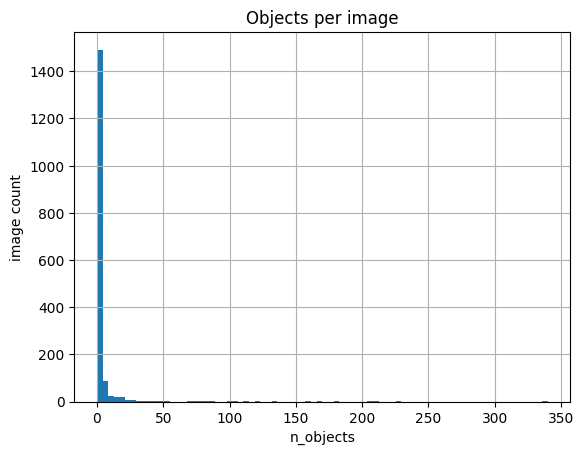

,image,split,region,modality,n_objects,valid_fraction,has_edge_object
3655,dataset_yolo_bbox/images/train/train_000703.png,train,027_ТИМЕРЕВО,Ae,340,1.000000,True
1942,dataset_yolo_bbox/images/train/train_000690.png,train,027_ТИМЕРЕВО,Li,229,0.701386,True
3995,dataset_yolo_bbox/images/train/train_000704.png,train,027_ТИМЕРЕВО,Ae,210,0.961516,True
3448,dataset_yolo_bbox/images/train/train_000702.png,train,027_ТИМЕРЕВО,Ae,207,1.000000,True
2377,dataset_yolo_bbox/images/train/train_000693.png,train,027_ТИМЕРЕВО,Li,182,0.696148,True
4273,dataset_yolo_bbox/images/train/train_000706.png,train,027_ТИМЕРЕВО,Ae,168,0.979159,True
2559,dataset_yolo_bbox/images/train/train_000694.png,train,027_ТИМЕРЕВО,Li,160,0.754129,True
3242,dataset_yolo_bbox/images/train/train_000700.png,train,027_ТИМЕРЕВО,Ae,134,0.950290,True
2171,dataset_yolo_bbox/images/train/train_000691.png,train,027_ТИМЕРЕВО,Li,122,0.616541,True
2719,dataset_yolo_bbox/images/train/train_000695.png,train,027_ТИМЕРЕВО,Li,119,0.647223,True


In [13]:
# 5. Распределение объектов на изображение
img_df["n_objects"].hist(bins=80)
plt.title("Objects per image")
plt.xlabel("n_objects")
plt.ylabel("image count")
plt.show()

img_df.sort_values("n_objects", ascending=False)[[
    "image", "split", "region", "modality",
    "n_objects", "valid_fraction", "has_edge_object"
]].head(50)

class_name
kurgany_povrezhdennye    3792
fortifikatsii            1172
kurgany_tselye           1097
arkhitektury              360
gorodishcha               260
Name: count, dtype: int64


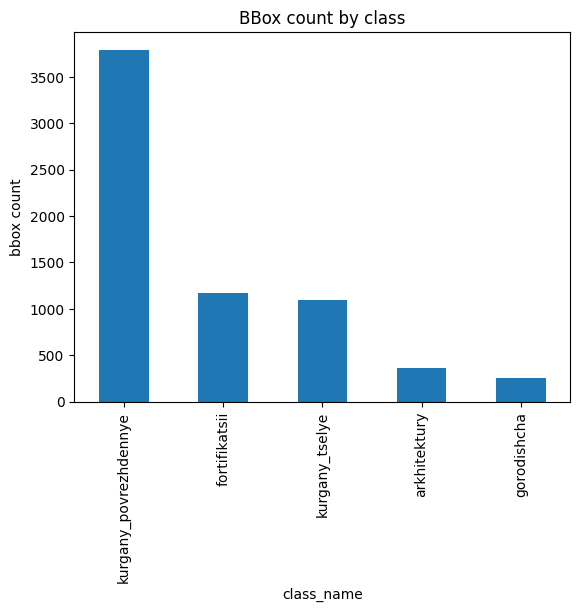

In [14]:
# 6. Баланс классов по bbox
box_df = df[df["is_positive"] == True].copy()

print(box_df["class_name"].value_counts())

box_df["class_name"].value_counts().plot(kind="bar")
plt.title("BBox count by class")
plt.ylabel("bbox count")
plt.show()

In [15]:
# 7. Площади bbox
box_df["bbox_area_px"].describe(percentiles=[
    .01, .05, .10, .25, .50, .75, .90, .95, .99
])

,bbox_area_px
count,6.681000e+03
mean,1.689718e+05
std,1.093278e+06
min,8.000000e+01
1%,1.100000e+02
5%,2.400000e+02
10%,5.290000e+02
25%,2.666000e+03
50%,2.096000e+04
75%,4.746000e+04


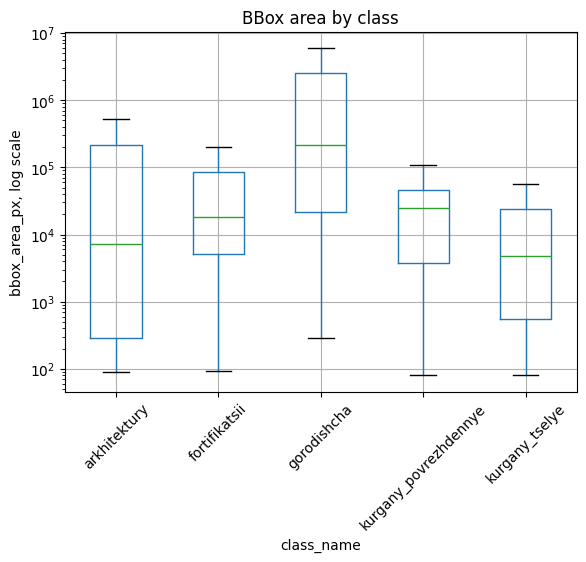

In [16]:
# 8. Площадь bbox по классам
box_df.boxplot(
    column="bbox_area_px",
    by="class_name",
    rot=45,
    showfliers=False
)
plt.yscale("log")
plt.title("BBox area by class")
plt.suptitle("")
plt.ylabel("bbox_area_px, log scale")
plt.show()

In [17]:
# 9. Подозрительно мелкие bbox
small_thr = box_df["bbox_area_px"].quantile(0.01)

small_boxes = box_df[box_df["bbox_area_px"] <= small_thr].copy()

print("small_thr:", small_thr)
print("small boxes:", len(small_boxes))

small_boxes[[
    "image", "class_name", "bbox_area_px",
    "bbox_x1_px", "bbox_y1_px", "bbox_x2_px", "bbox_y2_px",
    "modality", "region"
]].head(50)

small_thr: 110.0
small boxes: 69


,image,class_name,bbox_area_px,bbox_x1_px,bbox_y1_px,bbox_x2_px,bbox_y2_px,modality,region
174,dataset_yolo_bbox/images/train/train_000052.png,fortifikatsii,100.0,0.0,1020.0,5.0,1040.0,Ae,006_МОСКОВИТЫ
914,dataset_yolo_bbox/images/train/train_000311.png,kurgany_tselye,80.0,639.0,811.0,649.0,819.0,Li,017_ВЫШЕГЖА
943,dataset_yolo_bbox/images/train/train_000312.png,kurgany_tselye,84.0,0.0,872.0,6.0,886.0,Li,017_ВЫШЕГЖА
953,dataset_yolo_bbox/images/train/train_000314.png,kurgany_tselye,80.0,639.0,43.0,649.0,51.0,Li,017_ВЫШЕГЖА
954,dataset_yolo_bbox/images/train/train_000314.png,kurgany_tselye,84.0,716.0,0.0,728.0,7.0,Li,017_ВЫШЕГЖА
996,dataset_yolo_bbox/images/train/train_000315.png,kurgany_tselye,84.0,0.0,104.0,6.0,118.0,Li,017_ВЫШЕГЖА
1036,dataset_yolo_bbox/images/train/train_000316.png,kurgany_tselye,99.0,372.0,702.0,381.0,713.0,Li,017_ВЫШЕГЖА
5408,dataset_yolo_bbox/images/train/train_001214.png,kurgany_povrezhdennye,96.0,551.0,385.0,563.0,393.0,Ae,042_ИЗБОРСК
5414,dataset_yolo_bbox/images/train/train_001214.png,kurgany_povrezhdennye,100.0,822.0,645.0,832.0,655.0,Ae,042_ИЗБОРСК
5415,dataset_yolo_bbox/images/train/train_001214.png,kurgany_povrezhdennye,80.0,839.0,674.0,849.0,682.0,Ae,042_ИЗБОРСК


In [18]:
# 10. Подозрительно огромные bbox
large_thr = box_df["bbox_area_px"].quantile(0.99)

large_boxes = box_df[box_df["bbox_area_px"] >= large_thr].copy()

print("large_thr:", large_thr)
print("large boxes:", len(large_boxes))

large_boxes[[
    "image", "class_name", "bbox_area_px",
    "bbox_x1_px", "bbox_y1_px", "bbox_x2_px", "bbox_y2_px",
    "modality", "region"
]].head(50)

large_thr: 3053109.59999999
large boxes: 67


,image,class_name,bbox_area_px,bbox_x1_px,bbox_y1_px,bbox_x2_px,bbox_y2_px,modality,region
54,dataset_yolo_bbox/images/train/train_000029.png,fortifikatsii,4202660.0,0.0,2555.0,2729.0,4095.0,Li,006_МОСКОВИТЫ
59,dataset_yolo_bbox/images/train/train_000030.png,fortifikatsii,3673241.0,2584.0,0.0,4095.0,2431.0,Li,006_МОСКОВИТЫ
65,dataset_yolo_bbox/images/train/train_000031.png,fortifikatsii,7124160.0,0.0,0.0,2715.0,2624.0,Li,006_МОСКОВИТЫ
66,dataset_yolo_bbox/images/train/train_000031.png,fortifikatsii,4355313.0,214.0,154.0,2285.0,2257.0,Li,006_МОСКОВИТЫ
894,dataset_yolo_bbox/images/train/train_000297.png,gorodishcha,3200400.0,367.0,0.0,2047.0,1905.0,Li,016_ЗОЛОТАРЕВКА
1283,dataset_yolo_bbox/images/train/train_000450.png,gorodishcha,4190209.0,0.0,0.0,2047.0,2047.0,Li,023_ЕЛИЗАВЕТИНСКОЕ
1284,dataset_yolo_bbox/images/train/train_000451.png,gorodishcha,4190209.0,0.0,0.0,2047.0,2047.0,Li,023_ЕЛИЗАВЕТИНСКОЕ
1290,dataset_yolo_bbox/images/train/train_000456.png,gorodishcha,3115534.0,0.0,0.0,2047.0,1522.0,Li,023_ЕЛИЗАВЕТИНСКОЕ
1293,dataset_yolo_bbox/images/train/train_000457.png,gorodishcha,4190209.0,0.0,0.0,2047.0,2047.0,Li,023_ЕЛИЗАВЕТИНСКОЕ
1313,dataset_yolo_bbox/images/train/train_000469.png,gorodishcha,4231980.0,1329.0,2549.0,4095.0,4079.0,Or,023_ЕЛИЗАВЕТИНСКОЕ


In [19]:
# 11. Объекты, касающиеся края тайла
edge_boxes = box_df[box_df["bbox_touches_tile_edge"] == True]

print("edge boxes:", len(edge_boxes))
print("edge ratio:", len(edge_boxes) / len(box_df))

edge_boxes["class_name"].value_counts()

edge boxes: 1555
edge ratio: 0.2327495883849723


,count
class_name,
kurgany_povrezhdennye,647
fortifikatsii,503
gorodishcha,166
kurgany_tselye,160
arkhitektury,79


In [20]:
# 12. Leakage check по region/source_id
img_df["source_id"] = (
    img_df["region"].astype(str) + " | " +
    img_df["modality"].astype(str) + " | " +
    img_df["raster_file"].astype(str)
)

train = img_df[img_df["split"] == "train"]
val = img_df[img_df["split"] == "val"]

for col in ["region", "source_id", "raster_file"]:
    overlap = set(train[col]) & set(val[col])
    print(col, "overlap:", len(overlap))
    if overlap:
        print(list(overlap)[:10])

region overlap: 0
source_id overlap: 0
raster_file overlap: 0


In [21]:
# 13. Сводка по регионам: где самые тяжелые кластеры
region_stats = (
    img_df
    .groupby(["region", "modality"])
    .agg(
        images=("image", "nunique"),
        positives=("is_positive", "sum"),
        mean_objects=("n_objects", "mean"),
        max_objects=("n_objects", "max"),
        mean_valid_fraction=("valid_fraction", "mean"),
        edge_tile_ratio=("tile_touches_raster_edge", "mean"),
    )
    .sort_values("max_objects", ascending=False)
)

region_stats.head(30)

images  positives  \
region                                modality                      
027_ТИМЕРЕВО                          Ae             9          9   
                                      Li             9          9   
044_ГОЧЕВО                            Ae            28         21   
047_КАЛМЫКИЯ_1                        SpOr           1          1   
121_Курганы_2                         SpOr           2          2   
010_НОВЕНЬКОЕ                         Li            12          4   
091_Кисловодская_котловина_1          SpOr           2          2   
017_ВЫШЕГЖА                           Li            14          7   
119_Иссык_Куль_курганы_и_постройки_2 SpOr           1          1   
046_ТЫВА_2                            SpOr           1          1   
008_СЕЛЯНЕ                            Ae            39         15   
007_ЮШКОВО                            Ae            11          4   
058_СЕЛЬЦО                            Ae            96         16   
120_Курганы_1                         SpOr           1          1   
090_Артпозиции_Иссык_Куль             SpOr           1          1   
042_ИЗБОРСК                           Ae            19         17   
026_БОРОВИЧИ                          Li            91         83   
122_Курганы_3                         SpOr           1          1   
006_МОСКОВИТЫ                         Ae            41         31   
123_Курганы_4                         SpOr           2          2   
007_ЮШКОВО                            Li            20          6   
033_МИЛОВИДОВО_0.1км                  SpOr           2          2   
057_ШИШКИНО                           Ae            39         29   
117_Иссык_Куль_курганы_и_выкладки     SpOr           1          1   
116_Старый_Барах                     Or            56         22   
129_Курганы_10                        SpOr           2          2   
075_Сары_Булун                        SpOr           1          1   
125_Курганы_6                         SpOr           1          1   
048_КАЛМЫКИЯ_2                        SpOr           1          1   
008_СЕЛЯНЕ                            Li             6          5   

                                                mean_objects  max_objects  \
region                                modality                              
027_ТИМЕРЕВО                          Ae          157.222222          340   
                                      Li          132.888889          229   
044_ГОЧЕВО                            Ae           13.000000          100   
047_КАЛМЫКИЯ_1                        SpOr         52.000000           52   
121_Курганы_2                         SpOr         47.000000           52   
010_НОВЕНЬКОЕ                         Li            6.833333           48   
091_Кисловодская_котловина_1          SpOr         47.000000           47   
017_ВЫШЕГЖА                           Li            9.500000           45   
119_Иссык_Куль_курганы_и_постройки_2 SpOr         40.000000           40   
046_ТЫВА_2                            SpOr         39.000000           39   
008_СЕЛЯНЕ                            Ae            2.589744           38   
007_ЮШКОВО                            Ae            9.818182           36   
058_СЕЛЬЦО                            Ae            1.135417           36   
120_Курганы_1                         SpOr         33.000000           33   
090_Артпозиции_Иссык_Куль             SpOr         32.000000           32   
042_ИЗБОРСК                           Ae            6.210526           31   
026_БОРОВИЧИ                          Li            4.923077           31   
122_Курганы_3                         SpOr         28.000000           28   
006_МОСКОВИТЫ                         Ae            3.439024           28   
123_Курганы_4                         SpOr         27.000000           27   
007_ЮШКОВО                            Li            3.850000           25   
033_МИЛОВИДОВО_0.1км                  SpOr         19.500000        

In [22]:
# 14. Подготовить списки файлов для ручного просмотра
review_dir = Path("audit_lists")
review_dir.mkdir(exist_ok=True)

bad_tiles["image"].drop_duplicates().to_csv(
    review_dir / "bad_tile_candidates.txt",
    index=False,
    header=False
)

img_df.sort_values("n_objects", ascending=False)["image"].head(100).to_csv(
    review_dir / "top_100_dense_clusters.txt",
    index=False,
    header=False
)

small_boxes["image"].drop_duplicates().head(100).to_csv(
    review_dir / "small_bbox_candidates.txt",
    index=False,
    header=False
)

large_boxes["image"].drop_duplicates().head(100).to_csv(
    review_dir / "large_bbox_candidates.txt",
    index=False,
    header=False
)

print("Saved to:", review_dir)

Saved to: audit_lists


In [23]:
clean_img_df = img_df[
    (img_df["valid_fraction"] >= 0.90) &
    (img_df["tile_std"] >= img_df["tile_std"].quantile(0.02)) &
    (img_df["tile_p98_minus_p2"] >= img_df["tile_p98_minus_p2"].quantile(0.02))
].copy()

print("Before:", len(img_df))
print("After:", len(clean_img_df))
print("Removed:", len(img_df) - len(clean_img_df))

Before: 1693
After: 1489
Removed: 204


## 5. Build Filtered Dataset Variant

This cell materializes `v2` or `v4` from the original `dataset_yolo_bbox`. If `DATASET_VARIANT = "prebuilt"`, it uses the dataset from Drive unchanged.

In [6]:
from pathlib import Path
import random
import shutil
import pandas as pd

KEEP_MODALITIES = {"Li", "Ae"}
KEEP_OLD_CLASS_IDS = {0, 1}
CLASS_ID_MAP = {0: 0, 1: 1}
NAMES = {0: "kurgany_tselye", 1: "kurgany_povrezhdennye"}

def make_dirs(out_dir: Path):
    for split in ["train", "val"]:
        (out_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (out_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

def resolve_old_path(path_from_meta, old_dir, kind, split):
    p = Path(str(path_from_meta))
    if p.exists():
        return p
    candidate = old_dir / kind / split / p.name
    if candidate.exists():
        return candidate
    return p

def parse_yolo_label(path: Path):
    boxes = []
    if not path.exists():
        return boxes
    for line in path.read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id = int(float(parts[0]))
        coords = list(map(float, parts[1:]))
        if cls_id not in KEEP_OLD_CLASS_IDS:
            continue
        boxes.append((CLASS_ID_MAP[cls_id], *coords))
    return boxes

def valid_box(box):
    _, xc, yc, w, h = box
    return 0 <= xc <= 1 and 0 <= yc <= 1 and 0 < w <= 1 and 0 < h <= 1

def write_label(path: Path, boxes):
    lines = [f"{cls_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}" for cls_id, xc, yc, w, h in boxes]
    path.write_text("\n".join(lines), encoding="utf-8")

def write_yaml(out_dir: Path):
    text = f"""path: {out_dir.resolve()}

train: images/train
val: images/val

names:
  0: kurgany_tselye
  1: kurgany_povrezhdennye
"""
    (out_dir / "dataset.yaml").write_text(text, encoding="utf-8")

def build_filtered_dataset(old_dir: Path, variant: str):
    if variant == "v2":
        out_dir = DATA_ROOT / "dataset_yolo_bbox_v2_kurgans_li_ae"
        negative_ratio = 0.25
        min_valid_fraction = None
        min_contrast = None
        max_objects = None
        edge_ratio_limit = None
    elif variant == "v4":
        out_dir = DATA_ROOT / "dataset_yolo_bbox_v4_kurgans_li_ae_balanced"
        negative_ratio = 0.15
        min_valid_fraction = 0.25
        min_contrast = 3
        max_objects = 20
        edge_ratio_limit = 0.8
    elif variant == "prebuilt":
        return old_dir
    else:
        raise ValueError(f"Unknown DATASET_VARIANT: {variant}")

    if out_dir.exists():
        shutil.rmtree(out_dir)

    random.seed(42)
    make_dirs(out_dir)

    meta_path = old_dir / "metadata.csv"
    if not meta_path.exists():
        raise FileNotFoundError(f"metadata.csv is required to build {variant}: {meta_path}")

    meta = pd.read_csv(meta_path)
    images = meta.drop_duplicates("image").copy()
    images = images[images["modality"].isin(KEEP_MODALITIES)].copy()

    new_rows = []
    copied_images = 0
    positive_images = 0
    negative_images = 0
    total_boxes = 0
    bad_boxes = 0
    skipped_missing = 0

    for _, row in images.iterrows():
        split = row["split"]
        old_img = resolve_old_path(row["image"], old_dir, "images", split)
        old_lbl = resolve_old_path(row["label"], old_dir, "labels", split)

        if not old_img.exists():
            skipped_missing += 1
            continue

        if edge_ratio_limit is not None and "bbox_touches_tile_edge" in meta.columns:
            same_image = meta[meta["image"] == row["image"]]
            edge_ratio = same_image["bbox_touches_tile_edge"].fillna(False).mean()
            if edge_ratio > edge_ratio_limit:
                continue

        if min_valid_fraction is not None and "valid_fraction" in row and row["valid_fraction"] < min_valid_fraction:
            continue

        if min_contrast is not None and "tile_p98_minus_p2" in row and row["tile_p98_minus_p2"] < min_contrast:
            continue

        boxes = parse_yolo_label(old_lbl)
        boxes_ok = []
        for box in boxes:
            if valid_box(box):
                boxes_ok.append(box)
            else:
                bad_boxes += 1

        if max_objects is not None and len(boxes_ok) > max_objects:
            continue

        is_positive = len(boxes_ok) > 0
        if not is_positive and random.random() > negative_ratio:
            continue

        new_img = out_dir / "images" / split / old_img.name
        new_lbl = out_dir / "labels" / split / old_lbl.name
        shutil.copy2(old_img, new_img)
        write_label(new_lbl, boxes_ok)

        copied_images += 1
        total_boxes += len(boxes_ok)
        positive_images += int(is_positive)
        negative_images += int(not is_positive)

        base = row.to_dict()
        base["image"] = str(new_img)
        base["label"] = str(new_lbl)
        base["is_positive"] = bool(is_positive)
        base["n_objects"] = len(boxes_ok)

        if boxes_ok:
            for cls_id, xc, yc, w, h in boxes_ok:
                obj = base.copy()
                obj.update({"class_id": cls_id, "class_name": NAMES[cls_id], "yolo_xc": xc, "yolo_yc": yc, "yolo_w": w, "yolo_h": h})
                new_rows.append(obj)
        else:
            obj = base.copy()
            obj.update({"class_id": None, "class_name": None, "yolo_xc": None, "yolo_yc": None, "yolo_w": None, "yolo_h": None})
            new_rows.append(obj)

    new_meta = pd.DataFrame(new_rows)
    new_meta.to_csv(out_dir / "metadata.csv", index=False)
    write_yaml(out_dir)

    print("=" * 80)
    print(f"DONE: {variant}")
    print("dataset:", out_dir)
    print("images copied:", copied_images)
    print("positive images:", positive_images)
    print("negative images:", negative_images)
    print("total boxes:", total_boxes)
    print("bad boxes skipped:", bad_boxes)
    print("missing images skipped:", skipped_missing)
    if not new_meta.empty:
        print("\nBBoxes by class:")
        print(new_meta[new_meta["is_positive"]].groupby("class_name").size())

    return out_dir

TRAIN_DATASET_DIR = build_filtered_dataset(SOURCE_DATASET_DIR, DATASET_VARIANT)
DATA_YAML = TRAIN_DATASET_DIR / "dataset.yaml"

print("Training dataset:", TRAIN_DATASET_DIR)
print(DATA_YAML.read_text(encoding="utf-8"))

/tmp/ipykernel_2008/1745392523.py:113: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  edge_ratio = same_image["bbox_touches_tile_edge"].fillna(False).mean()


DONE: v4
dataset: /content/dataset/dataset_yolo_bbox_v4_kurgans_li_ae_balanced
images copied: 347
positive images: 226
negative images: 121
total boxes: 772
bad boxes skipped: 0
missing images skipped: 0

BBoxes by class:
class_name
kurgany_povrezhdennye    430
kurgany_tselye           342
dtype: int64
Training dataset: /content/dataset/dataset_yolo_bbox_v4_kurgans_li_ae_balanced
path: /content/dataset/dataset_yolo_bbox_v4_kurgans_li_ae_balanced

train: images/train
val: images/val

names:
  0: kurgany_tselye
  1: kurgany_povrezhdennye



## 6. Train YOLOv8

In [7]:
from ultralytics import YOLO

model = YOLO(MODEL_NAME)

train_result = model.train(
    data=str(DATA_YAML),
    imgsz=IMGSZ,
    epochs=EPOCHS,
    batch=BATCH,
    patience=PATIENCE,
    cos_lr=COS_LR,
    workers=WORKERS,
    cache=CACHE,
    close_mosaic=CLOSE_MOSAIC,
    project="/content/runs/detect",
    name=RUN_NAME,
    exist_ok=True,
)

RUN_DIR = Path("/content/runs/detect") / RUN_NAME
BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"
if not BEST_WEIGHTS.exists():
    # Older Ultralytics versions sometimes save weights directly in run dir.
    alt = RUN_DIR / "best.pt"
    if alt.exists():
        BEST_WEIGHTS = alt

print("Run dir:", RUN_DIR)
print("Best weights:", BEST_WEIGHTS)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/dataset_yolo_bbox_v4_kurgans_li_ae_balanced/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=Fal

## 7. Optional Threshold Validation

In [8]:
from ultralytics import YOLO

THRESHOLD_RUN_DIRS = []

if RUN_THRESHOLD_VALIDATION:
    if not BEST_WEIGHTS.exists():
        raise FileNotFoundError(f"Best weights not found: {BEST_WEIGHTS}")

    val_model = YOLO(str(BEST_WEIGHTS))
    for conf in CONF_THRESHOLDS:
        val_name = f"{RUN_NAME}_val_conf_{str(conf).replace('.', '_')}"
        metrics = val_model.val(
            data=str(DATA_YAML),
            imgsz=IMGSZ,
            conf=conf,
            project="/content/runs/detect",
            name=val_name,
            exist_ok=True,
            plots=True,
        )
        out_dir = Path("/content/runs/detect") / val_name
        THRESHOLD_RUN_DIRS.append(out_dir)
        print("conf:", conf, "save_dir:", out_dir)
else:
    print("Threshold validation skipped")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3263.8±660.7 MB/s, size: 856.8 KB)
val: Scanning /content/dataset/dataset_yolo_bbox_v4_kurgans_li_ae_balanced/labels/val.cache... 43 images, 14 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 20.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.9s/it 5.8s
                   all         43         87      0.484      0.202      0.204      0.122
        kurgany_tselye          7         16      0.345      0.264      0.272      0.182
 kurgany_povrezhdennye         29         71      0.623      0.141      0.136     0.0625
Speed: 35.0ms preprocess, 29.1ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/kurgans_li_ae_v4_yolov8s_balanced_colab_val_conf_0_1
conf: 0.1 s

## 8. Summarize Training Metrics

In [9]:
import pandas as pd

results_csv = RUN_DIR / "results.csv"
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    metric_cols = ["epoch", "metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]
    metric_cols = [c for c in metric_cols if c in df.columns]
    print("Last epoch metrics:")
    display(df[metric_cols].tail(1))
    if "metrics/mAP50(B)" in df.columns:
        best_idx = df["metrics/mAP50(B)"].idxmax()
        print("Best mAP50 epoch metrics:")
        display(df.loc[[best_idx], metric_cols])
else:
    print("results.csv not found:", results_csv)

Last epoch metrics:


,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
72,73,0.3142,0.18134,0.15278,0.08118


Best mAP50 epoch metrics:


,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
47,48,0.48504,0.20424,0.21359,0.1259


## 9. Archive Results To Google Drive

The archive includes training plots, CSV/YAML files, validation images, and optionally model weights.

In [10]:
from datetime import datetime
import zipfile

DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
archive_path = DRIVE_OUTPUT_DIR / f"{ARCHIVE_PREFIX}_{DATASET_VARIANT}_{RUN_NAME}_{timestamp}.zip"

include_suffixes = {".csv", ".yaml", ".yml", ".png", ".jpg", ".jpeg", ".txt"}
if INCLUDE_WEIGHTS_IN_ARCHIVE:
    include_suffixes.add(".pt")

dirs_to_archive = [RUN_DIR] + THRESHOLD_RUN_DIRS

with zipfile.ZipFile(archive_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for directory in dirs_to_archive:
        if not directory.exists():
            continue
        for file in directory.rglob("*"):
            if not file.is_file():
                continue
            if file.suffix.lower() not in include_suffixes:
                continue
            arcname = file.relative_to(Path("/content/runs/detect"))
            zf.write(file, arcname=arcname)

    # Save dataset metadata/yaml used for this training run.
    for file in [DATA_YAML, TRAIN_DATASET_DIR / "metadata.csv"]:
        if file.exists():
            zf.write(file, arcname=Path("dataset") / file.name)

print("Archive saved:", archive_path)
print("Archive size MB:", round(archive_path.stat().st_size / (1024 * 1024), 2))

Archive saved: /content/drive/MyDrive/Share/Geodata/yolo_detection_runs/yolo_kurgan_detection_v4_kurgans_li_ae_v4_yolov8s_balanced_colab_20260605_131149.zip
Archive size MB: 65.73


## 10. Download Archive Manually If Needed

The archive is already saved to Google Drive. This optional cell also exposes it for direct browser download from Colab.

In [11]:
from google.colab import files

# Uncomment if you want Colab to download the archive directly to your local machine.
# files.download(str(archive_path))

print("Drive archive:", archive_path)

Drive archive: /content/drive/MyDrive/Share/Geodata/yolo_detection_runs/yolo_kurgan_detection_v4_kurgans_li_ae_v4_yolov8s_balanced_colab_20260605_131149.zip
